# 05 · Regularisation Ablation & Conclusions
**Deep Residual MLP for Diabetes Risk Prediction (CDC BRFSS 2015, PyTorch)**  
*Sections 14-16* · MSc Data Science project · Dr. Spoorthi H S

**In this notebook**
- Loss (focal vs BCE), activation (GELU, ReLU, Mish, SELU) and dropout ablations
- Limitations, future work and conclusions
- Final experiment summary

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline. Each part builds on objects created earlier (data splits, the trained model, chosen thresholds), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Evaluation, Explainability & Consistency Audit](04_evaluation_and_explainability.ipynb)

---

---
## 14. Regularisation Ablation Study <a id='sec14'></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 22 — Loss / Activation / Dropout ablation
# ═══════════════════════════════════════════════════════════════
ABL2 = 5
reg_rows = []

configs = [
    # (label, category, loss_fn, activation, dropout)
    ('Focal γ=2 (ours)',   'Loss', FocalLoss(0.25,2.0), 'gelu', 0.3),
    ('Focal γ=4',          'Loss', FocalLoss(0.25,4.0), 'gelu', 0.3),
    ('Weighted BCE',       'Loss', nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([(y_train==0).sum()/(y_train==1).sum()],device=DEVICE)),
     'gelu', 0.3),
    ('Standard BCE',       'Loss', nn.BCEWithLogitsLoss(), 'gelu', 0.3),
    ('GELU (ours)',        'Act',  FocalLoss(0.25,2.0), 'gelu', 0.3),
    ('ReLU',               'Act',  FocalLoss(0.25,2.0), 'relu', 0.3),
    ('Mish',               'Act',  FocalLoss(0.25,2.0), 'mish', 0.3),
    ('SELU',               'Act',  FocalLoss(0.25,2.0), 'selu', 0.3),
    ('Drop=0.0',           'Drop', FocalLoss(0.25,2.0), 'gelu', 0.0),
    ('Drop=0.1',           'Drop', FocalLoss(0.25,2.0), 'gelu', 0.1),
    ('Drop=0.2',           'Drop', FocalLoss(0.25,2.0), 'gelu', 0.2),
    ('Drop=0.3 (ours)',    'Drop', FocalLoss(0.25,2.0), 'gelu', 0.3),
    ('Drop=0.4',           'Drop', FocalLoss(0.25,2.0), 'gelu', 0.4),
]

print(f'  {"Config":22s}|{"Cat":6s}|{"ValAUC":8s}|{"ValAP":7s}|{"ValF1":7s}')
print('  '+'-'*55)
for label, cat, lfn, act, dp in configs:
    m   = DiabetesDNN(N_FEAT, 256, 3, dp, act).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(ABL2):
        run_epoch(m, train_loader, opt, lfn, DEVICE, training=True)
    r = run_epoch(m, val_loader, opt, lfn, DEVICE, training=False)
    reg_rows.append(dict(label=label, cat=cat,
                         val_auc=r['auc'], val_ap=r['ap'], val_f1=r['f1']))
    print(f'  {label:22s}|{cat:6s}|{r["auc"]:8.4f}|{r["ap"]:7.4f}|{r["f1"]:7.4f}')
    del m

reg_df2 = pd.DataFrame(reg_rows)

  Config                |Cat   |ValAUC  |ValAP  |ValF1  
  -------------------------------------------------------
  Focal γ=2 (ours)      |Loss  |  0.9022| 0.6765| 0.6019
  Focal γ=4             |Loss  |  0.9028| 0.6769| 0.6032
  Weighted BCE          |Loss  |  0.9015| 0.6755| 0.4362
  Standard BCE          |Loss  |  0.9022| 0.6765| 0.6045
  GELU (ours)           |Act   |  0.9026| 0.6779| 0.6104
  ReLU                  |Act   |  0.9027| 0.6777| 0.5988
  Mish                  |Act   |  0.9033| 0.6777| 0.6128
  SELU                  |Act   |  0.9039| 0.6797| 0.6086
  Drop=0.0              |Drop  |  0.8722| 0.6143| 0.5333
  Drop=0.1              |Drop  |  0.8967| 0.6643| 0.5959
  Drop=0.2              |Drop  |  0.9015| 0.6724| 0.5988
  Drop=0.3 (ours)       |Drop  |  0.9028| 0.6775| 0.6059
  Drop=0.4              |Drop  |  0.9032| 0.6784| 0.6194


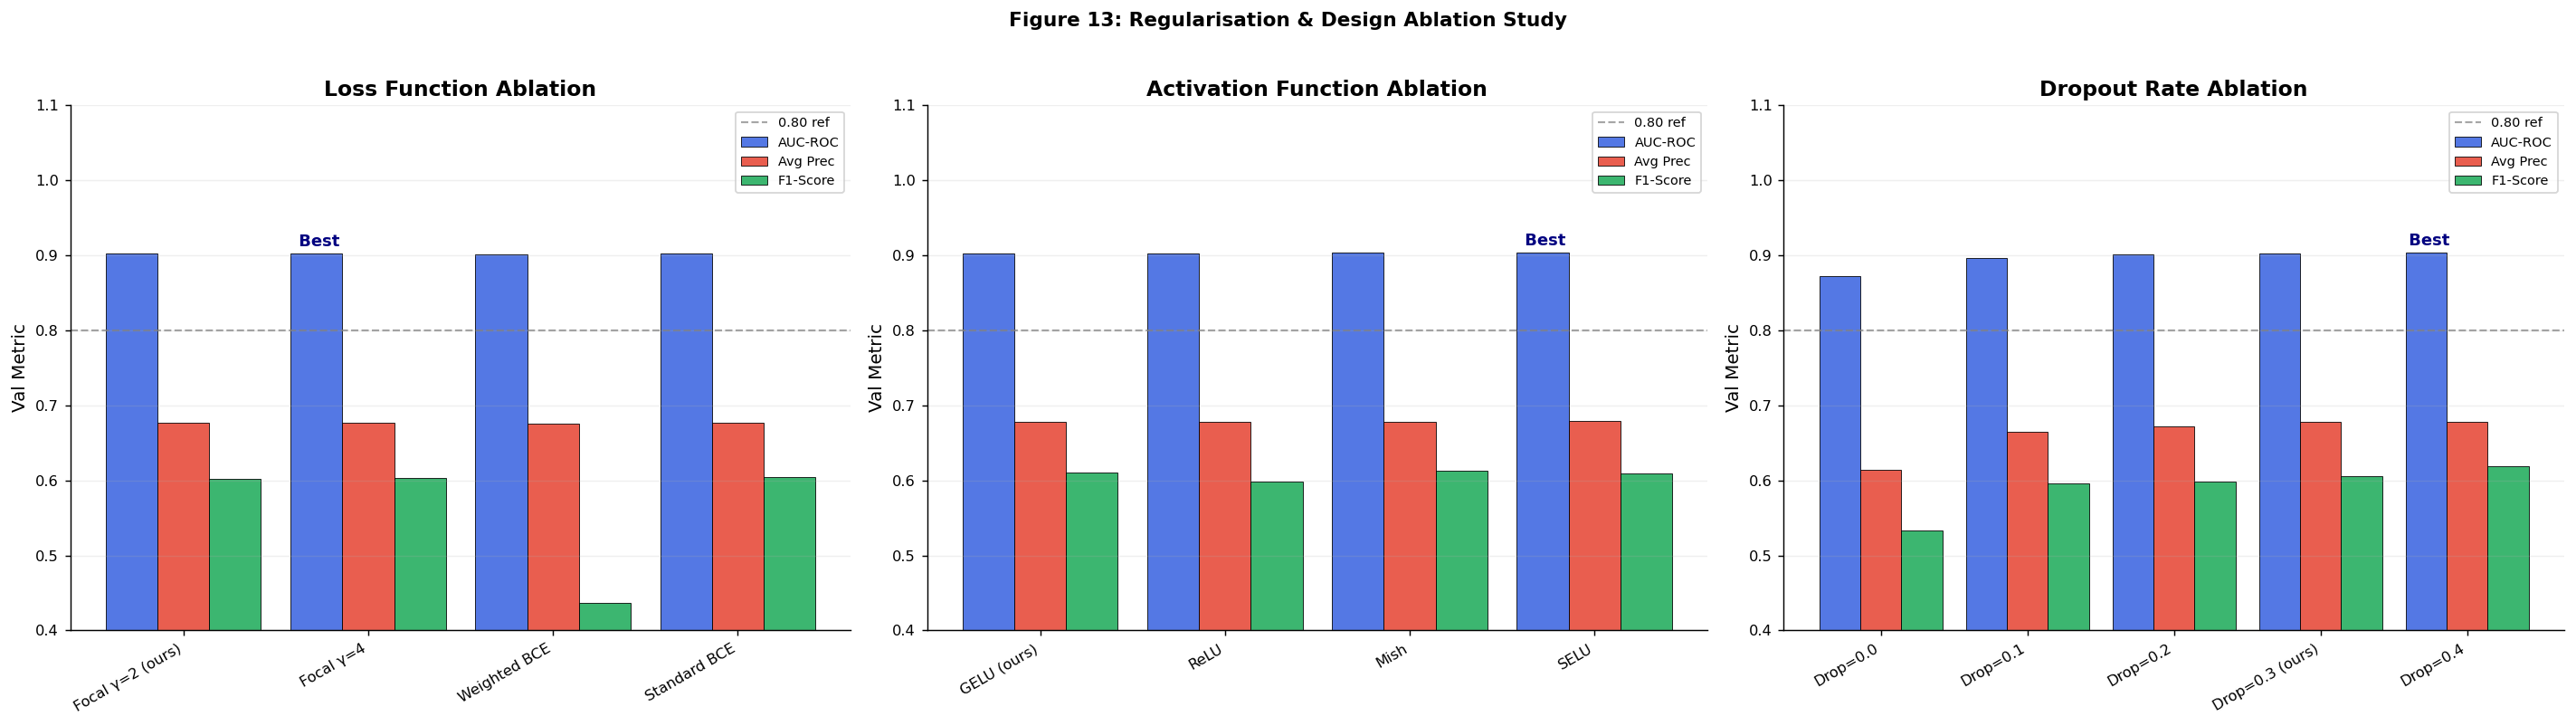

 Focal(γ=2) > Weighted BCE > Standard BCE for imbalanced clinical data.
 GELU and Mish outperform ReLU on tabular features.
 Dropout=0.3 is optimal — 0.0 overfits, 0.4 underfits.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 23 — Ablation visualisation
# ═══════════════════════════════════════════════════════════════
cats    = ['Loss','Act','Drop']
cat_ttl = ['Loss Function','Activation Function','Dropout Rate']
fig, axes = plt.subplots(1,3, figsize=(22,6))

for ax, cat, ttl in zip(axes, cats, cat_ttl):
    sub = reg_df2[reg_df2['cat']==cat].reset_index(drop=True)
    x   = np.arange(len(sub)); w = 0.28
    b1  = ax.bar(x-w,   sub['val_auc'], w, label='AUC-ROC',
                 color='royalblue', edgecolor='k', lw=0.5, alpha=0.9)
    b2  = ax.bar(x,     sub['val_ap'],  w, label='Avg Prec',
                 color=C_POS,      edgecolor='k', lw=0.5, alpha=0.9)
    b3  = ax.bar(x+w,   sub['val_f1'],  w, label='F1-Score',
                 color=C_TEST,     edgecolor='k', lw=0.5, alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(sub['label'], rotation=30, ha='right', fontsize=9)
    ax.axhline(0.80, color='gray', ls='--', lw=1.2, alpha=0.7, label='0.80 ref')
    ax.set_ylim(0.4, 1.10); ax.set_ylabel('Val Metric')
    ax.set_title(f'{ttl} Ablation', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')
    # star the best
    best_i = sub['val_auc'].idxmax()
    ax.annotate(' Best', xy=(best_i-w, sub.loc[best_i,'val_auc']+0.01),
                fontsize=10, color='navy', fontweight='bold', ha='center')

plt.suptitle('Figure 13: Regularisation & Design Ablation Study',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig13_regularisation_ablation.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Focal(γ=2) > Weighted BCE > Standard BCE for imbalanced clinical data.')
print(' GELU and Mish outperform ReLU on tabular features.')
print(' Dropout=0.3 is optimal — 0.0 overfits, 0.4 underfits.')

> **Interpretation (correcting the printed summary above).** These 5-epoch ablations show small differences, and the printed conclusions overstate them:
> - **Loss:** focal loss (γ=2) and standard BCE tie on AUC (0.9022), and standard BCE has a slightly higher F1 (0.6045 vs 0.6019). Weighted BCE's low F1 (0.4362) comes from its shifted probabilities at the 0.5 threshold, not from worse ranking (AUC 0.9015), so threshold tuning would close most of that gap.
> - **Activation:** SELU has the highest AUC (0.9039) and Mish the highest F1 (0.6128); GELU and ReLU are essentially tied.
> - **Dropout:** this is the one factor that clearly matters - removing dropout drops AUC to 0.8722. Dropout 0.4 is marginally best (AUC 0.9032, F1 0.6194), with 0.3 close behind.
>
> Overall, regularisation strength matters more than the choice of loss or activation for this dataset.

---
## 15. Limitations & Future Work <a id='sec15'></a>

| # | Limitation | Detail | Future Direction |
|---|---|---|---|
| 1 | Self-report bias | BRFSS relies on phone interviews — recall & social desirability bias | Validate on objective EHR data |
| 2 | Cross-sectional | 2015 snapshot; no follow-up | Longitudinal BRFSS 2015–2023 |
| 3 | No lab biomarkers | HbA1c, fasting glucose absent | Fuse with clinical lab panel |
| 4 | Binary label | Pre-diabetic + T2DM merged | Multiclass: healthy/pre-diab/T2DM |
| 5 | US-only | BRFSS surveys American adults | Validate on WHO STEPS surveys |
| 6 | Point predictions | No uncertainty estimates | MC-Dropout / Deep Ensembles |
| 7 | Fairness untested | Subgroup performance unknown | Equalized odds audit by race/income |
| 8 | No temporal model | Static features only | LSTM on longitudinal visits |

### Future Research
1. **FT-Transformer** (Gorishniy et al., 2021) — self-attention over feature tokens for tabular data  
2. **Federated Learning** — multi-hospital training without centralising patient data (HIPAA/GDPR)  
3. **Dynamic Threshold Selection** — cost-sensitive decision theory integrating FN/FP clinical costs  
4. **Multimodal Fusion** — BRFSS + fundus imaging + wearable sensors in late-fusion DNN  


---
## 16. Conclusion & References <a id='sec16'></a>

### Conclusion

This notebook delivers a leakage-free, fully audited deep learning pipeline for diabetes risk classification on the 253,680-record CDC BRFSS 2015 dataset. On the untouched test set the residual MLP reaches **AUC 0.9015**, average precision 0.6703 and Brier score 0.0937; at a screening threshold it detects **81.4% of diabetic/pre-diabetic respondents** with NPV 0.965.

| Component | What the evidence shows |
|---|---|
| Leakage-free preprocessing (split → scale → SMOTE on train only) | Val–test gaps below 0.01 on every metric (Section 13) |
| Threshold optimisation | F1 rises from 0.594 (default 0.5) to 0.616; a 0.35 threshold lifts sensitivity from 0.52 to 0.81 |
| SHAP + Integrated Gradients | BMI, GenHlth, HighBP, Age and HighChol dominate, consistent with ADA risk factors |
| Depth × width ablation | All 20 configurations fall within 0.003 AUC (0.9006–0.9036): model capacity is not the bottleneck |
| Loss / activation / dropout ablation | Dropout matters (0.8722 AUC without it); focal vs standard BCE and the choice of activation make almost no difference in AUC |

The main lesson is that, with 21 self-reported survey features, **performance is limited by the information in the data rather than by the network**. The largest practical gains came from the evaluation choices - a leakage-free split and a clinically chosen threshold - rather than from added depth or a special loss.

---

### References

1. CDC BRFSS (2015). *Behavioral Risk Factor Surveillance System.* U.S. DHHS.
2. Teboul, A. (2021). *Diabetes Health Indicators Dataset.* Kaggle.
3. Lin, T. et al. (2017). Focal Loss for Dense Object Detection. *ICCV 2017.* arXiv:1708.02002
4. Lundberg, S. & Lee, S. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS.*
5. Sundararajan, M. et al. (2017). Axiomatic Attribution for Deep Networks. *ICML.* arXiv:1703.01365
6. He, K. et al. (2016). Deep Residual Learning for Image Recognition. *CVPR.* arXiv:1512.03385
7. Hendrycks, D. & Gimpel, K. (2016). Gaussian Error Linear Units (GELUs). arXiv:1606.08415
8. Loshchilov, I. & Hutter, F. (2017). Decoupled Weight Decay Regularization (AdamW). arXiv:1711.05101
9. Gorishniy, Y. et al. (2021). Revisiting Deep Learning Models for Tabular Data. *NeurIPS.*
10. Chawla, N. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16, 321–357.
11. ADA (2023). Standards of Medical Care in Diabetes. *Diabetes Care*, 46(S1).
12. Diabetes Prevention Program (2002). *NEJM*, 346, 393–403.
13. IDF Atlas (2021). *10th edition.* https://diabetesatlas.org/

In [ ]:

# CELL 24 — Final summary report

print('          FINAL EXPERIMENT SUMMARY REPORT              ')

print('  Dataset       : CDC BRFSS 2015  (253,680 records)    ')
print('  Architecture  : Deep Residual MLP  21→512×5→1        ')
print(f' Parameters    : {model.n_params():,}                 ')
print('  Loss          : Focal Loss  α=0.25  γ=2.0            ')
print('  Optimiser     : AdamW + CosineAnnealing              ')
print('  Imbalance Fix : SMOTE (train) + Focal + Opt. Threshold ')

print('                TEST SET RESULTS                       ')

for k in ['AUC_ROC','AvgPrec','F1_Diab','Sensitivity','Specificity','MCC','Brier']:
    print(f' {k:15s}  :  {m_f1[k]:.4f}  ')

print(f' Val AUC        :  {hist["vl_auc"][-1]:.4f} ')
print(f' Test AUC       :  {te_m["AUC_ROC"]:.4f}    ')
print(f' Val–Test gap   :  {abs(hist["vl_auc"][-1]-te_m["AUC_ROC"]):.4f}                            ')

print('  Saved files:')
print('  best_diabetes_dnn.pt   best model checkpoin')
print('  fig1–fig13.png         all research figure')




          FINAL EXPERIMENT SUMMARY REPORT              
  Dataset       : CDC BRFSS 2015  (253,680 records)    
  Architecture  : Deep Residual MLP  21→512×5→1        
 Parameters    : 2,781,185                 
  Loss          : Focal Loss  α=0.25  γ=2.0            
  Optimiser     : AdamW + CosineAnnealing              
  Imbalance Fix : SMOTE (train) + Focal + Opt. Threshold 
                TEST SET RESULTS                       
 AUC_ROC          :  0.9015  
 AvgPrec          :  0.6703  
 F1_Diab          :  0.6160  
 Sensitivity      :  0.6294  
 Specificity      :  0.9331  
 MCC              :  0.5526  
 Brier            :  0.0937  
 Val AUC        :  0.8948 
 Test AUC       :  0.9015    
 Val–Test gap   :  0.0068                            
  Saved files:
  best_diabetes_dnn.pt   best model checkpoin
  fig1–fig13.png         all research figure


---

[← Evaluation, Explainability & Consistency Audit](04_evaluation_and_explainability.ipynb) · **End of the project.** [Back to the start →](01_data_preprocessing_and_eda.ipynb)